<a href="https://colab.research.google.com/github/ahmdltf/Dicoding/blob/main/preprocessing/Eksperimen_AhmadLatif.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# ======================
# INSTALL LIBRARY (jika di Colab)
# ======================
!pip install ucimlrepo

# ======================
# IMPORT LIBRARY UTAMA
# ======================
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Dataset UCI
from ucimlrepo import fetch_ucirepo

# Utility
import os

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# ======================
# LOAD DATASET DARI UCI
# ======================

df = pd.read_csv("../online_retail_raw/online_retail.csv")

# Informasi dataset
print(df.info())

# 5 data awal
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

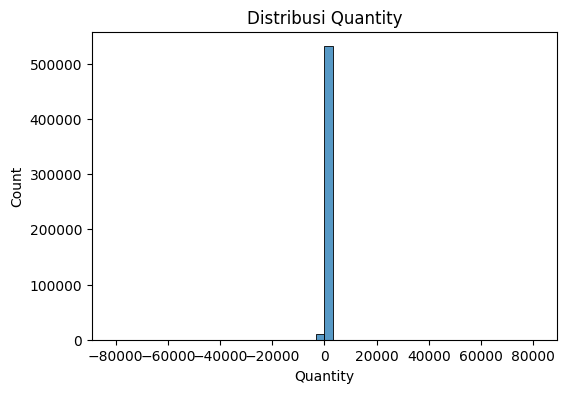

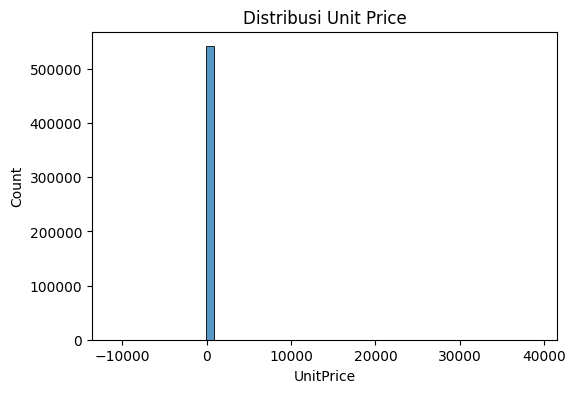

In [3]:
# ======================
# FETCH DATASET METADATA
# ======================

online_retail = fetch_ucirepo(id=352)

# data
X = online_retail.data.features
y = online_retail.data.targets

# metadata dataset
print(online_retail.metadata)

# informasi variabel
print(online_retail.variables)

# ======================
# EDA SEDERHANA
# ======================

plt.figure(figsize=(6,4))
sns.histplot(df["Quantity"], bins=50)
plt.title("Distribusi Quantity")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df["UnitPrice"], bins=50)
plt.title("Distribusi Unit Price")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# ======================
# DATA CLEANING
# ======================

# Menghapus transaksi cancel
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Menghapus missing customer
df = df.dropna(subset=["CustomerID"])

# Menghapus quantity tidak valid
df = df[df["Quantity"] > 0]


# ======================
# FEATURE ENGINEERING
# ======================

# Membuat total belanja
df["TotalSpend"] = df["Quantity"] * df["UnitPrice"]

# Membuat target klasifikasi
threshold = df["TotalSpend"].median()
df["HighValueCustomer"] = (
    df["TotalSpend"] > threshold
).astype(int)

# Ekstraksi fitur waktu
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day

# Menghapus kolom tanggal asli
df.drop("InvoiceDate", axis=1, inplace=True)


# ======================
# DROP KOLOM TIDAK DIGUNAKAN
# ======================

df.drop(
    ["InvoiceNo", "StockCode", "CustomerID"],
    axis=1,
    inplace=True
)


# ======================
# ENCODING DATA KATEGORIKAL
# ======================

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])


# ======================
# SCALING FITUR
# ======================

target = "HighValueCustomer"
X_cols = df.columns.drop(target)

scaler = StandardScaler()
df[X_cols] = scaler.fit_transform(df[X_cols])


# ======================
# MENYIMPAN DATASET BARU
# ======================

os.makedirs("online_retail_preprocessing", exist_ok=True)

df.to_csv(
    "online_retail_preprocessing/online_retail_clean.csv",
    index=False
)

print("Dataset preprocessing berhasil disimpan!")

Dataset preprocessing berhasil disimpan!
